<div style="background:linear-gradient(135deg,#603813 0%,#b29f94 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">♻️&nbsp; Benchmark: Transfer Learning vs. Training from Scratch</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">When you solve a <i>family</i> of related PDEs, why start cold every time? We pre-train on one viscosity, then fine-tune on another — and compare against training from scratch.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">type</span><span style="background:#603813;color:#fff;padding:4px 8px;">benchmark</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">transfer learning</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">~1 min · CPU</span></span></div>

A network trained to solve Burgers at one viscosity has already learned the *shape* of the solution
family. Fine-tuning it for a new viscosity should converge **faster** than a fresh network — the
core promise of transfer learning.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">1 · Setup</a></li>
  <li style="margin:3px 0;"><a href="#pretrain" style="color:#1a73e8;text-decoration:none;">2 · Pre-train on the Source Task</a></li>
  <li style="margin:3px 0;"><a href="#compare" style="color:#1a73e8;text-decoration:none;">3 · Fine-tune vs. From-Scratch</a></li>
  <li style="margin:3px 0;"><a href="#result" style="color:#1a73e8;text-decoration:none;">4 · Convergence Comparison</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">5 · Takeaways</a></li>
  </ol>
</div>

<a id="setup"></a>

## 1 · Setup

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinnlab").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnlab
print(f"pinnlab      : {pinnlab.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinnlab      : 0.5.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


In [2]:
from pinnlab.models import MLP
from pinnlab.solvers.raissi_improved import (
    BurgersConfig, TrainConfig, ContinuousPINN, burgers_residual)

SOURCE = BurgersConfig(nu=0.05)            # easier, smoother task
TARGET = BurgersConfig(nu=0.01/np.pi)      # harder, sharper task
print(f"Source ν = {SOURCE.nu:.5f}  ->  Target ν = {TARGET.nu:.5f}")

def fresh_model():
    torch.manual_seed(SEED); np.random.seed(SEED)
    return MLP(2, 4, 32, 1)

target_cfg = TrainConfig(n_u0=120, n_bc=80, n_f=1_200, adam_steps=1_000,
                         lbfgs_max_iter=0, seed=SEED, track_losses=True)

Source ν = 0.05000  ->  Target ν = 0.00318


<a id="pretrain"></a>

## 2 · Pre-train on the Source Task

In [3]:
src_model = fresh_model()
src_pinn = ContinuousPINN(src_model, DEVICE, burgers_residual, SOURCE)
src_pinn.train(TrainConfig(n_u0=120, n_bc=80, n_f=1_200, adam_steps=1_000,
                           lbfgs_max_iter=0, seed=SEED, track_losses=True),
               weights=(10.0, 1.0, 1.0))
print("Source model pre-trained.")
pretrained_state = {k: v.clone() for k, v in src_model.state_dict().items()}

Source model pre-trained.


<a id="compare"></a>

## 3 · Fine-tune vs. From-Scratch

Two identical networks tackle the **target** task — one initialised from the pre-trained weights, the other from scratch — with the same budget.

In [4]:
# (a) Transfer: start from pre-trained weights
t_model = fresh_model(); t_model.load_state_dict(pretrained_state)
transfer_pinn = ContinuousPINN(t_model, DEVICE, burgers_residual, TARGET)
hist_transfer = transfer_pinn.train(target_cfg, weights=(10.0, 1.0, 1.0))

# (b) Scratch: random initialisation
s_model = fresh_model()
scratch_pinn = ContinuousPINN(s_model, DEVICE, burgers_residual, TARGET)
hist_scratch = scratch_pinn.train(target_cfg, weights=(10.0, 1.0, 1.0))

print(f"Transfer  final loss: {hist_transfer['total'][-1]:.3e}")
print(f"Scratch   final loss: {hist_scratch['total'][-1]:.3e}")

Transfer  final loss: 2.003e-01
Scratch   final loss: 3.298e-01


<a id="result"></a>

## 4 · Convergence Comparison

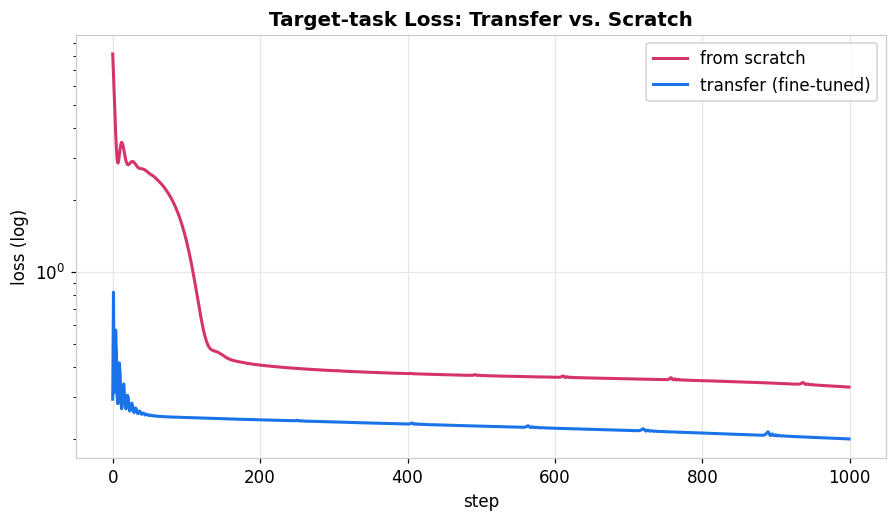

Transfer reaches 2.46e-01 by step 100.
Scratch did not reach that loss within the budget.


In [5]:
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(hist_scratch["total"],  color=ACCENT2, lw=2, label="from scratch")
ax.plot(hist_transfer["total"], color=ACCENT,  lw=2, label="transfer (fine-tuned)")
ax.set_yscale("log"); ax.set(title="Target-task Loss: Transfer vs. Scratch",
                             xlabel="step", ylabel="loss (log)")
ax.legend(); plt.show()

# How many steps for the scratch model to reach the transfer model's loss at step 100?
mark = hist_transfer["total"][100]
reached = next((i for i, v in enumerate(hist_scratch["total"]) if v <= mark), None)
print(f"Transfer reaches {mark:.2e} by step 100.")
print(f"Scratch reaches the same loss at step {reached}." if reached else
      "Scratch did not reach that loss within the budget.")

<div style="background:#e9f9ee;border-left:5px solid #1e9e54;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>✅ Tip.</b> The transfer curve typically <i>starts lower and stays lower</i> — the network reuses the solution structure it already learned, so fine-tuning is a head start, not a cold start.
</div>

<a id="takeaways"></a>

## 5 · Takeaways

- **Transfer learning** pays off whenever you solve many related PDEs (parameter sweeps, design
  optimisation, families of boundary conditions).
- A model pre-trained on an easier task gives a warm start that converges faster on a harder one.
- The library's `pinnlab.transfer` module (`TransferLearningPINN`, `PretrainingManager`,
  `progressive_complexity_schedule`) formalises this into reusable pre-training pipelines.

### 📚 References

1. Goswami, S. et al. (2020). *Transfer learning enhanced PINNs for brittle fracture*. Theoretical and Applied Fracture Mechanics, 106.
2. Desai, S. et al. (2021). *One-shot transfer learning of PINNs*. arXiv:2110.11286.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinnlab</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>